# Foundation Models
## Assignment 7 - Foundation models for information extraction

Please complete the questions below by modifying this notebook and submit to OLAT. The deadline for this assignment is 08.06.2026, 10:00 AM.

Programming assignments have to be completed using Python 3. __Please do not use Python 2.__

__Always explain your answers__ (do not just write 'yes' or 'no')

Please add your name and matriculation number below:

__Name:__ ANURAG YADAV
<br>
__Mat. No.:__ 224201226

----

## 1. Precision@k

You are given the dataset with following samples and their prediction scores and ground truth labels
| Sample | Predicted scores           | Ground truth labels |
| ---    | -------------------------- | ------------------- |
| 1      | \[0.9, 0.1, 0.3, 0.6, 0.2] | \[1, 0, 0, 1, 0]    |
| 2      | \[0.2, 0.8, 0.7, 0.1, 0.4] | \[0, 1, 1, 0, 0]    |
| 3      | \[0.5, 0.2, 0.9, 0.4, 0.6] | \[0, 0, 1, 1, 0]    |
| 4      | \[0.1, 0.7, 0.2, 0.5, 0.8] | \[0, 1, 0, 0, 1]    |
| 5      | \[0.6, 0.9, 0.4, 0.3, 0.2] | \[1, 0, 0, 0, 0]    |
| 6      | \[0.3, 0.4, 0.8, 0.6, 0.1] | \[0, 0, 1, 1, 0]    |
| 7      | \[0.7, 0.2, 0.1, 0.9, 0.4] | \[0, 1, 0, 1, 0]    |
| 8      | \[0.4, 0.5, 0.3, 0.7, 0.2] | \[1, 0, 0, 1, 0]    |
| 9      | \[0.2, 0.6, 0.8, 0.3, 0.9] | \[0, 1, 1, 0, 1]    |
| 10     | \[0.5, 0.3, 0.4, 0.7, 0.2] | \[0, 0, 0, 1, 0]    |

With $k=3$, compute $precision@3$ for each sample and mean $precision@3$ for the whole dataset.


In [ ]:
prediction_labels = [0.9, 0.1, 0.3, 0.6, 0.2]
target_labels = [1,0,0,1,0]
k = 3

# so, here we need to sort the prediction_labels and also keep track of their original indices to get the corresponding target_labels
def calculate_precision_at_k(prediction_labels, target_labels, k):
    # Get the indices of the top k predictions
    # sort the indices based on values present at those indices, in reverse, extract k values
    top_k_indices = sorted(range(len(prediction_labels)), key=lambda i: prediction_labels[i], reverse=True)[:k]
    
    # print(top_k_indices)

    # Get the corresponding target labels for the top k predictions
    top_k_target_labels = [target_labels[i] for i in top_k_indices]
    # print(top_k_target_labels)
    # Calculate precision at k
    true_positives = sum(top_k_target_labels)
    # print(true_positives)
    precision_at_k = true_positives / k
    return precision_at_k

precision = calculate_precision_at_k(prediction_labels, target_labels, k)
print(f"Precision at {k}: {precision:.2f}")

[0, 3, 2]
[1, 1, 0]
2
Precision at 3: 0.67


In [27]:
predictions = [
    [0.9, 0.1, 0.3, 0.6, 0.2],
    [0.2, 0.8, 0.7, 0.1, 0.4],
    [0.5, 0.2, 0.9, 0.4, 0.6],
    [0.1, 0.7, 0.2, 0.5, 0.8],
    [0.6, 0.9, 0.4, 0.3, 0.2],
    [0.3, 0.4, 0.8, 0.6, 0.1],
    [0.7, 0.2, 0.1, 0.9, 0.4],
    [0.4, 0.5, 0.3, 0.7, 0.2],
    [0.2, 0.6, 0.8, 0.3, 0.9],
    [0.5, 0.3, 0.4, 0.7, 0.2]
]


targets = [
    [1, 0, 0, 1, 0],
    [0, 1, 1, 0, 0],
    [0, 0, 1, 1, 0],
    [0, 1, 0, 0, 1],
    [1, 0, 0, 0, 0],
    [0, 0, 1, 1, 0],
    [0, 1, 0, 1, 0],
    [1, 0, 0, 1, 0],
    [0, 1, 1, 0, 1],
    [0, 0, 0, 1, 0]
]

dataset_precision = []

for idx in range(len(predictions)):
    dataset_precision.append(calculate_precision_at_k(predictions[idx], targets[idx], 3))


print(f"Mean precision@3 for dataset: {sum(dataset_precision)/len(dataset_precision):.2f}")


Mean precision@3 for dataset: 0.57


## 2. BERT: Multiclass Text Classification
In this tutorial, we will use the BERT model for multiclass generation. 

Dataset: **Conference**

The dataset contains 2,507 research paper titles, and have been manually classified into 5 categories (i.e. conferences) that can be downloaded from here: https://raw.githubusercontent.com/susanli2016/NLP-with-Python/master/data/title_conference.csv 

### Tasks:
a. Use a BERT model for multiclass classification on the **Conference** dataset  (refer to Exercise 5 for an example using BERT for binary classification). Split the dataset using an 80:20 ratio for training and testing. You may choose any of the following pre-trained models: `bert-base-cased`, `bert-base-uncased`, `bert-large-uncased`, `bert-large-cased`

Suggested hyperparameters:
- Learning rate: 2e-5
- Batch size: 16
- Maximum sequence length: 256
- Number of epochs: 10

b. Train the model using 100 samples from the dataset.

c. Save the trained model to a file named bert_conference_model.pt.

d. Plot the training loss and accuracy during training.

e. Test the model with at least three paper titles.

f. Evaluate the model on the test set (20% of the data) and report the classification performance.

g. Try other pre-trained models such as distilbert-base-uncased or roberta-base, and compare their performance with bert-base-uncased.

h. Experiment with training on more data, potentially using the entire dataset.


In [11]:
# Library Imports:
# Import libraries
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import AdamW #Improved version of the Adam optimizer
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from tqdm import tqdm #Progress bar

# Check GPU
device = "cpu"

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")

Using device: mps


In [12]:
# Load the dataset (use the first 100 rows)
from sympy import limit


df = pd.read_csv("title_conference.csv", nrows=500)

# Encode sentiment labels to numerical values
label_encoder = LabelEncoder()
df['Conference'] = label_encoder.fit_transform(df['Conference'])

In [13]:
df["Conference"].unique()

array([3, 1, 2, 0, 4])

In [14]:
# Define custom dataset
class ConferenceDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts # this takes in a list of conference titles [t1,t2,t3]
        self.labels = labels # corresponding labels of the confernece titles [0,1,3,0 ...]
        self.tokenizer = tokenizer # tokenizer from bert-base
        self.max_len = max_len # max_len? max length of input token we process

    def __len__(self):
        return len(self.texts) # returns number of samples

    def __getitem__(self, idx): # get a training example by index
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [15]:
# Tokenize and split dataset
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
dataset = ConferenceDataset(df['Title'].tolist(), df['Conference'].tolist(), tokenizer)

# Split: 80% train, 20% test
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Data loaders
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [9]:
len(dataset)


500

In [16]:
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=5)
model.to(device)

# Define optimizer
optimizer = AdamW(model.parameters(), lr=2e-5)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [17]:
# Training loop
epochs = 10
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in tqdm(train_loader):
        # move input to device 
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward() #Compute gradient 
        optimizer.step() #Update weights

        total_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_losses.append(total_loss / len(train_loader))
    train_accuracies.append(correct / total)
    print(f"Epoch {epoch+1}: Loss = {train_losses[-1]:.4f}, Accuracy = {train_accuracies[-1]:.4f}")

100%|██████████| 25/25 [01:28<00:00,  3.53s/it]


Epoch 1: Loss = 1.5388, Accuracy = 0.3275


100%|██████████| 25/25 [01:23<00:00,  3.33s/it]


Epoch 2: Loss = 1.3127, Accuracy = 0.4600


100%|██████████| 25/25 [01:22<00:00,  3.29s/it]


...

Epoch 8: Loss = 0.0679, Accuracy = 0.9975


100%|██████████| 25/25 [01:29<00:00,  3.56s/it]


Epoch 9: Loss = 0.0430, Accuracy = 1.0000


100%|██████████| 25/25 [01:20<00:00,  3.22s/it]

Epoch 10: Loss = 0.0300, Accuracy = 1.0000


In [18]:
# Save trained model
torch.save(model.state_dict(), "bert_conference_model.pt")

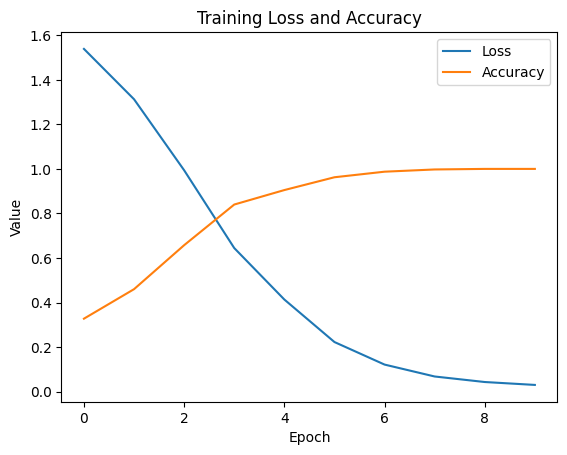

In [19]:
# Plot loss and accuracy curves
plt.plot(train_losses, label='Loss')
plt.plot(train_accuracies, label='Accuracy')
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.show()

In [20]:
# Load the model for inference
model_loaded = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=5)
model_loaded.load_state_dict(torch.load("bert_conference_model.pt"))
model_loaded.to(device)
model_loaded.eval()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [21]:
# define the test run loop:
with torch.no_grad():
    correct, total = 0, 0
    test_accuracy = 0
    for batch in tqdm(test_loader):
        # move input to device 
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    test_accuracy = correct/total
    print("Number of test samples: ", total)
    print(f"Accuracy = {test_accuracy:.4f}")



100%|██████████| 7/7 [00:07<00:00,  1.03s/it]

Number of test samples:  100
Accuracy = 0.8400


## PEFT based LoRA parameter tuning

### Comparison of PEFT LoRA fine-tuning vs full-fine tuning